In [1]:
pip install librosa matplotlib numpy scipy praat-parselmouth


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 49.5 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


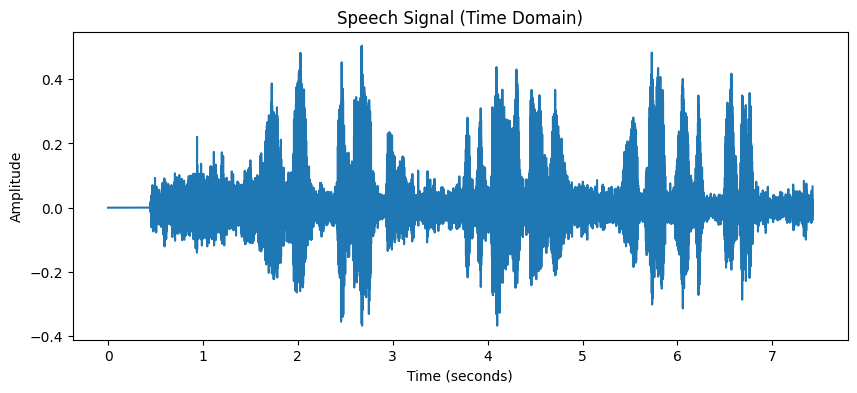

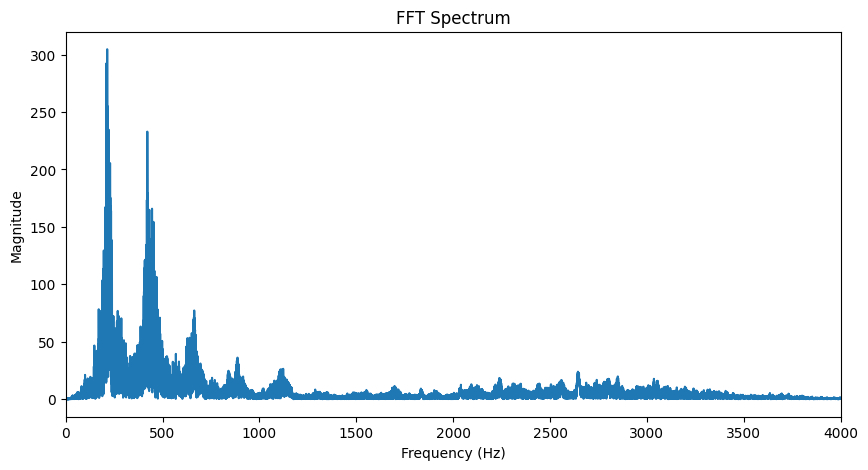

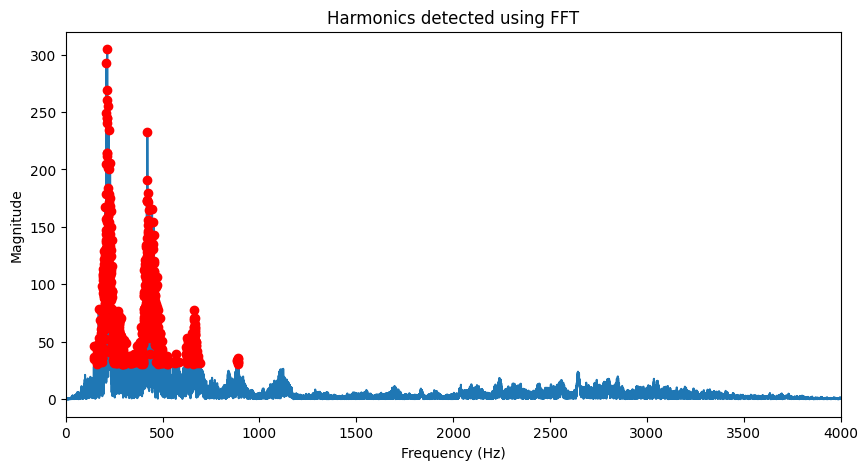

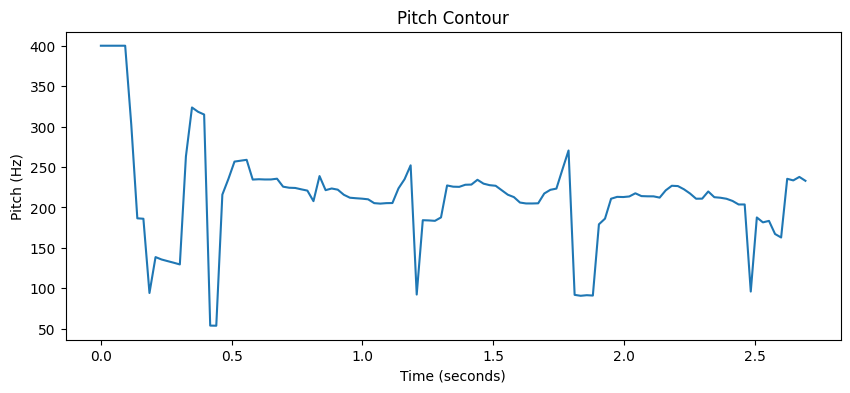

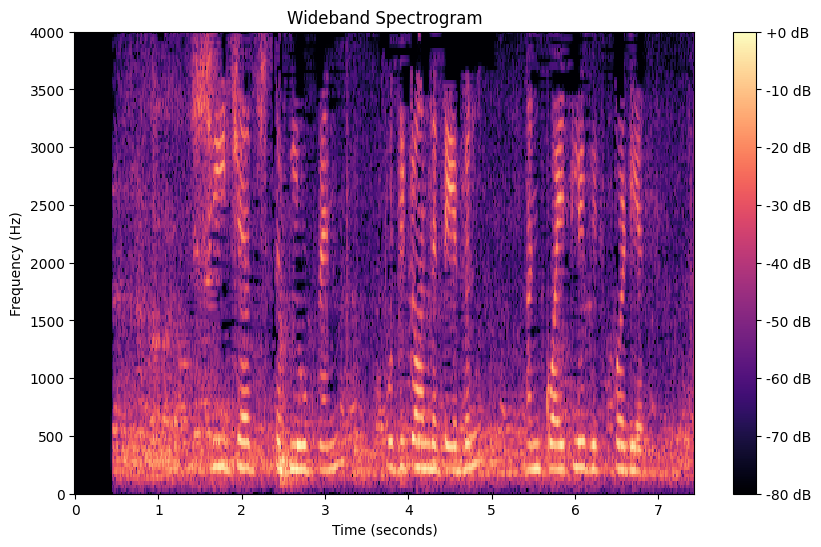

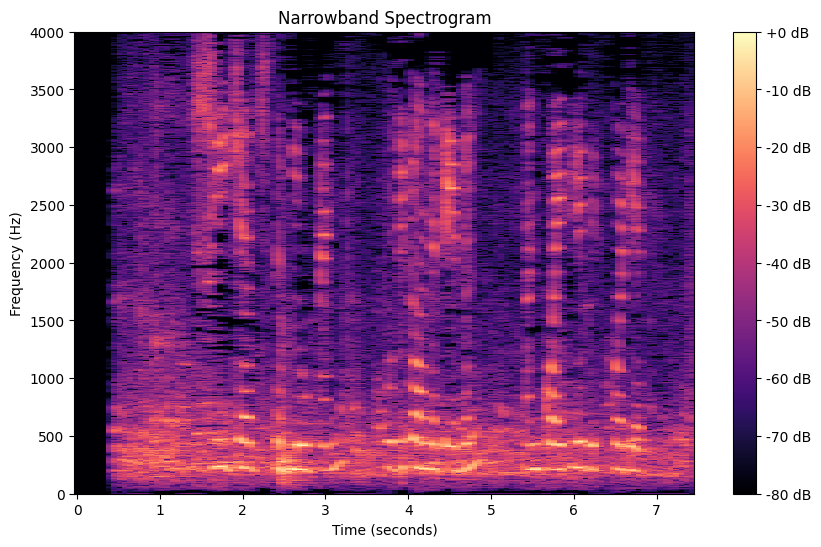

In [8]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -------------------------------
# Load speech file
# -------------------------------

file_path = "/content/drive/MyDrive/audio.wav"

signal, sr = librosa.load(file_path, sr=None)

time = np.linspace(0, len(signal)/sr, len(signal))

# -------------------------------
# Plot Speech Signal
# -------------------------------

plt.figure(figsize=(10,4))
plt.plot(time, signal)
plt.title("Speech Signal (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


# ------------------------------------------------
# I. FFT – Frequency Spectrum
# ------------------------------------------------

fft = np.fft.fft(signal)
magnitude = np.abs(fft)

freq = np.fft.fftfreq(len(magnitude), 1/sr)

# Keep only positive frequencies
mask = freq >= 0
freq = freq[mask]
magnitude = magnitude[mask]

plt.figure(figsize=(10,5))
plt.plot(freq, magnitude)
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0,4000)
plt.show()


# ------------------------------------------------
# Detect Harmonics (Peaks in FFT)
# ------------------------------------------------

peaks, _ = find_peaks(magnitude, height=max(magnitude)*0.1)

plt.figure(figsize=(10,5))
plt.plot(freq, magnitude)
plt.plot(freq[peaks], magnitude[peaks], "ro")
plt.title("Harmonics detected using FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0,4000)
plt.show()


# ------------------------------------------------
# Pitch estimation
# ------------------------------------------------

pitch = librosa.yin(signal,
                    fmin=50,
                    fmax=400,
                    sr=sr)

times = librosa.times_like(pitch)

plt.figure(figsize=(10,4))
plt.plot(times, pitch)
plt.title("Pitch Contour")
plt.xlabel("Time (seconds)")
plt.ylabel("Pitch (Hz)")
plt.show()






# ------------------------------------------------
# III. Wideband Spectrogram
# ------------------------------------------------

wideband_stft = librosa.stft(signal, n_fft=256, hop_length=128)

wideband_spec = np.abs(wideband_stft)

plt.figure(figsize=(10,6))

librosa.display.specshow(
    librosa.amplitude_to_db(wideband_spec, ref=np.max),
    sr=sr,
    hop_length=128,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Wideband Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0,4000)

plt.show()



# ------------------------------------------------
# IV. Narrowband Spectrogram
# ------------------------------------------------

narrowband_stft = librosa.stft(signal, n_fft=2048, hop_length=512)

narrowband_spec = np.abs(narrowband_stft)

plt.figure(figsize=(10,6))

librosa.display.specshow(
    librosa.amplitude_to_db(narrowband_spec, ref=np.max),
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Narrowband Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0,4000)

plt.show()

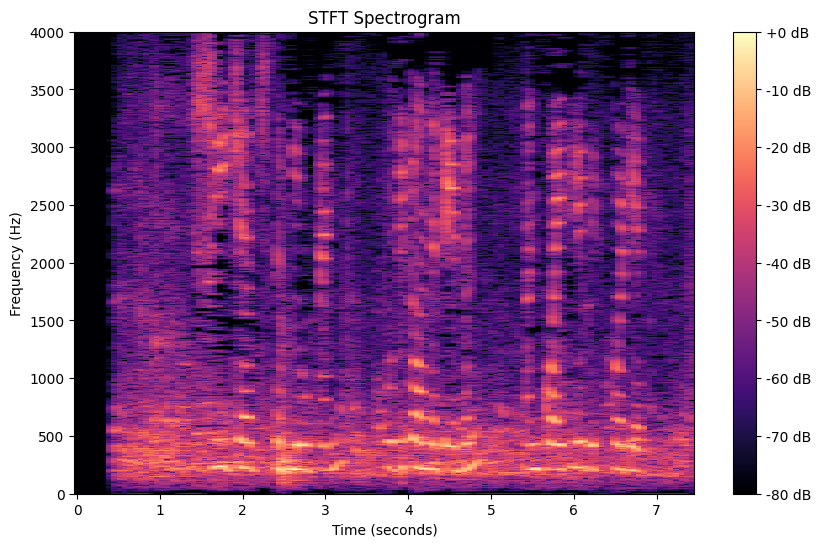

In [9]:
# STFT – Spectrogram

stft = librosa.stft(signal)

spectrogram = np.abs(stft)

plt.figure(figsize=(10,6))

librosa.display.specshow(
    librosa.amplitude_to_db(spectrogram, ref=np.max),
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("STFT Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0,4000)

plt.show()